# Size Effects

A tutorial on evaluating box size and trajectory time for KBI convergence via *KBIntegrator*

In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from natsort import natsorted

from kbkit.io import RdfParser
from kbkit.kbi import KBIntegrator
from kbkit.systems import SystemProperties
from kbkit.utils.exceptions import KBIConvergenceError

warnings.filterwarnings("always")

In [35]:
# create functions for plotting
from matplotlib.colors import Normalize

from kbkit.visualization.format import style_axes, style_legend


def get_molpair(mol1, mol2):
    mol1, mol2 = mol1.upper(), mol2.upper()
    for idx, (moli, molj) in enumerate(mol_pairs):
        if (moli == mol1) and (molj == mol2):
            return idx, (moli, molj)
        elif (moli == mol2) and (molj == mol1):
            return idx, (moli, molj)


def plot_times(kbint_dict, key, mols, plot_forced=True, cmap="hsv", dpi=125):
    colors = plt.colormaps[cmap](np.linspace(0.1, 1, 5))
    lw = 1
    fitls = (0, (3, 2))
    fitcolor = "k"
    fitlw = 2

    ii, mols = get_molpair(*mols)
    bb = list(dict.fromkeys(kbint_dict)).index(key)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), dpi=dpi)
    ax1, ax2, ax3 = axes
    for ax in axes:
        style_axes(ax, minorxticks=np.arange(0, 3, 0.5))

    res1 = kbint_dict[key]
    for t, (time, res2) in enumerate(res1.items()):
        integ = res2[mols]

        ax1.plot(integ.r, integ.gr_vdv, lw=lw, color=colors[t], label=f"{time} ns")
        integ.add_kbi(ax2, weight_type="geometric", lw=lw, color=colors[t], label=f"{time} ns")

        value = kbis_converged[bb, t, ii]
        label = ""
        if np.isnan(value):
            if plot_forced:
                fitres = integ.compute_geometric_extrapolation(
                    positions=(integ.r.max() - 1, integ.r.max()), maximize_r2=False, errors="ignore"
                )
                label = rf"G$^\infty_{{{time}ns}}$={fitres['G']:.4f} (r$^2$={fitres['r2']:.3f})"
                ax3.plot(fitres["r_fit"], fitres["r_rkbi_pred"], lw=fitlw, color=fitcolor, ls=fitls, zorder=10)
        else:
            label = rf"G$^\infty_{{{time}ns}}$={value:.4f} (r$^2$={integ.geometric_extrapolation_result['r2']:.3f})"
            integ.add_lkbi_fit(ax3, lw=fitlw, color=fitcolor, ls=fitls, zorder=10)
        integ.add_lkbi(ax3, lw=lw, color=colors[t], label=label)

    style_legend(ax2, ncol=2, framealpha=0.5, fontsize=11)
    style_legend(ax3, ncol=1, fontsize=11, framealpha=0.5)

    ax1.set_ylim(0.995, 1.005)
    ax1.set_xlabel("R (nm)")
    ax1.set_ylabel(r"g$^\text{vdV}$(r)")
    ax2.set_xlabel("R (nm)")
    ax2.set_ylabel(r"G$^\text{V}$(R) (nm$^3$)")
    ax3.set_xlabel("R (nm)")
    ax3.set_ylabel(r"RG$^\text{V}$(R) (nm $\cdot$ nm$^3$)")
    lab = f"{key} nm" if key > 1 else f"8 nm (v{key})"
    fig.suptitle(f"{molmap[mols[0]]}-{molmap[mols[1]]} KBI Analysis for Boxlength={lab}", fontsize=18)


def plot_heatmap(axhandle, mol1, mol2, add_cbar=True):
    mol_idx, mols = get_molpair(mol1, mol2)

    data = np.abs(kbis_converged_perc)[:, :, mol_idx]
    data_forced = np.abs(kbis_forced_perc)[:, :, mol_idx]

    # Plot first dataset in blue
    im = axhandle.imshow(
        data,
        aspect="auto",
        origin="lower",
        cmap="Blues",
        norm=Normalize(vmin=0, vmax=50),
        interpolation="nearest",
    )

    # Overlay second dataset in red (with transparency to see both)
    im2 = axhandle.imshow(
        data_forced,
        aspect="auto",
        origin="lower",
        cmap="Reds",
        norm=Normalize(vmin=0, vmax=50),
        alpha=0.6,
        interpolation="nearest",
    )

    axhandle.set_xticks(range(len(times)))
    axhandle.set_xticklabels(times)
    axhandle.set_yticks(range(len(boxlengths)))
    axhandle.set_yticklabels(boxlengths)

    # Annotate all values - perc in black, forced in red
    for b in range(len(boxlengths)):
        for t in range(len(times)):
            val_perc = kbis_all_perc[b, t, mol_idx]
            color = "black" if abs(val_perc) <= 45 else "white"
            axhandle.text(t, b, f"{val_perc:.1f}", ha="center", va="center", fontsize=12, color=color)

    # Individual colorbars
    if add_cbar:
        cbar = plt.colorbar(im, ax=axhandle, orientation="vertical", pad=0.02, extend="max")
        cbar.set_label("Converged (% Dev)", fontsize=12)
        cbar.outline.set(linewidth=1, edgecolor="k", linestyle="-")
        cbar.ax.tick_params(width=0.75)
        cbar2 = plt.colorbar(im2, ax=axhandle, orientation="vertical", pad=0.04, extend="max")
        cbar2.set_label("Forced (% Dev)", fontsize=12)
        cbar2.outline.set(linewidth=1, edgecolor="k", linestyle="-")
        cbar2.ax.tick_params(width=0.75)


def plot_rkbi_heatmap(mol1, mol2, figsize=(13, 7), dpi=110, cmap="hsv", plot_forced=True):
    mol_idx, mols = get_molpair(mol1, mol2)
    colors = plt.colormaps[cmap](np.linspace(0.1, 1, 5))

    fig, axes = plt.subplots(2, 3, figsize=figsize, dpi=dpi)
    axf = list(axes.flat)
    lett = ["A", "B", "C", "D", "E", "F"]

    lw = 1
    fitls = (0, (3, 2))
    fitcolor = "k"
    fitlw = 2

    for b, (box, boxdict) in enumerate(kbints.items()):
        for t, (time, timedict) in enumerate(boxdict.items()):
            integ = timedict[mols]

            value = kbis_converged[b, t, mol_idx]
            label = ""
            if np.isnan(value):
                if plot_forced:
                    fitres = integ.compute_geometric_extrapolation(
                        positions=(integ.r.max() - 1, integ.r.max()), maximize_r2=False, errors="ignore"
                    )
                    label = rf"G$^\infty_{{{time}ns}}$={fitres['G']:.4f}"
                    axf[b].plot(fitres["r_fit"], fitres["r_rkbi_pred"], lw=fitlw, color=fitcolor, ls=fitls, zorder=10)
            else:
                label = rf"G$^\infty_{{{time}ns}}$={value:.4f}"
                integ.add_lkbi_fit(axf[b], lw=fitlw, color=fitcolor, ls=fitls, zorder=10)
            integ.add_lkbi(axf[b], lw=lw, color=colors[t], label=label)

        style_axes(axf[b])
        axf[b].set_xlabel(r"$R$ (nm)")
        axf[b].set_ylabel(r"$R \ G_{ij}^R$ (nm$^4$)")
        axf[b].set_title(f"{lett[b]}) Boxlength = {box} nm")
        style_legend(axf[b], framealpha=0.7, fontsize=11)

    plot_heatmap(axf[-1], *mols)
    style_axes(axf[-1], gridon=False, majorticklength=5)
    axf[-1].set_xlabel("Time (ns)")
    axf[-1].set_ylabel("Boxlength (nm)")
    axf[-1].set_title(f"{lett[-1]}) KBI % Deviation")

    fig.suptitle(f"KBI Analysis for {molmap[mols[0]]}-{molmap[mols[1]]}", fontsize=20)


def plot_kbi_vs_time(kbint_dict, kbi_c_arr, kbi_f_arr, kbi_all_arr, cmap="hsv", dpi=110):
    colors = plt.colormaps[cmap](np.linspace(0.15, 1, len(boxlengths)))

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.75), sharex=True, dpi=dpi)
    for b, boxlength in enumerate(kbint_dict):
        axes[0].plot(
            times,
            kbi_c_arr[b, :, 0],
            marker="o",
            color=colors[b],
            fillstyle="none",
            mew=1.5,
            ms=8,
            ls="",
            alpha=1,
            label=f"{boxlength}",
        )
        axes[1].plot(
            times,
            kbi_c_arr[b, :, 1],
            marker="o",
            color=colors[b],
            fillstyle="none",
            mew=1.5,
            ms=8,
            ls="",
            alpha=1,
            label=f"{boxlength}",
        )
        axes[2].plot(
            times,
            kbi_c_arr[b, :, 2],
            marker="o",
            color=colors[b],
            fillstyle="none",
            mew=1.5,
            ms=8,
            ls="",
            alpha=1,
            label=f"{boxlength}",
        )

        # for non-converged values
        axes[0].plot(
            times,
            kbi_f_arr[b, :, 0],
            marker="^",
            color=colors[b],
            fillstyle="full",
            mew=1,
            ms=8,
            ls="",
            alpha=1,
            label=f"{boxlength} (force)",
        )
        axes[1].plot(
            times,
            kbi_f_arr[b, :, 1],
            marker="^",
            color=colors[b],
            fillstyle="full",
            mew=1,
            ms=8,
            ls="",
            alpha=1,
            label=f"{boxlength} (force)",
        )
        axes[2].plot(
            times,
            kbi_f_arr[b, :, 2],
            marker="^",
            color=colors[b],
            fillstyle="full",
            mew=1,
            ms=8,
            ls="",
            alpha=1,
            label=f"{boxlength} (force)",
        )

        # add lines for all values
        axes[0].plot(times, kbi_all_arr[b, :, 0], color=colors[b], ls="-", lw=1.2)
        axes[1].plot(times, kbi_all_arr[b, :, 1], color=colors[b], ls="-", lw=1.2)
        axes[2].plot(times, kbi_all_arr[b, :, 2], color=colors[b], ls="-", lw=1.2)

    axes[0].set_ylabel(r"KBI (nm$^3$)")

    style_legend(axes[0], ncol=2, fontsize=11, framealpha=0.5)

    for i in range(len(mol_pairs)):
        axes[i].set_xlabel("Time (ns)")
        axes[i].set_title(f"{molmap[mol_pairs[i][0]]}-{molmap[mol_pairs[i][0]]}")
        style_axes(axes[i])

    plt.show()

In [26]:
# map system numbers to box size
system_map = {3.2: "sys_704", 4: "sys_706", 6: "sys_701", 8: "sys_705", 10: "sys_406"}


# get system-path from boxsize
def get_syspath(boxsize):
    return Path(f"./test_data/size_effects/{system_map[boxsize]}")

In [27]:
# get mol name from moltype in GROMACS file
molmap = {"ETHOL": "Ethanol", "SPCEW": "Water"}

In [28]:
# we need to create KBIntegrator objects for each boxsize-time combo


def extract_time(text: str):
    return int(re.search(r"\d+", text).group())


# first get boxsizes and times
boxlengths = list(dict.fromkeys(system_map))
times = set()
mol_pairs = set()

kbints = {L: {} for L in boxlengths}
for L in boxlengths:
    syspath = get_syspath(L)
    sysprop = SystemProperties(syspath, start_time=10000, include="npt")

    # get all rdf-paths
    rdf_paths = natsorted(syspath.glob("*rdf*ns*"))

    # now iterate through all rdf-paths
    for path in rdf_paths:
        time = extract_time(path.name)
        times.add(time)
        print(f"Analyzing: {L=}nm, {time=}ns")
        for f in natsorted(path.glob("*.xvg")):
            # get KBInt obj
            integ = KBIntegrator.from_rdf(rdf_file=f, system_properties=sysprop, errors="raise", force=False)
            rdf_mols = tuple(RdfParser.extract_molecules(f.name, sysprop.get("molecules")))
            kbints[L].setdefault(time, {})[rdf_mols] = integ
            mol_pairs.add(rdf_mols)

Analyzing: L=3.2nm, time=10ns
Analyzing: L=3.2nm, time=50ns
Analyzing: L=3.2nm, time=100ns
Analyzing: L=3.2nm, time=150ns
Analyzing: L=3.2nm, time=200ns
Analyzing: L=4nm, time=10ns
Analyzing: L=4nm, time=50ns
Analyzing: L=4nm, time=100ns
Analyzing: L=4nm, time=150ns
Analyzing: L=4nm, time=200ns
Analyzing: L=6nm, time=10ns
Analyzing: L=6nm, time=50ns
Analyzing: L=6nm, time=100ns
Analyzing: L=6nm, time=150ns
Analyzing: L=6nm, time=200ns
Analyzing: L=8nm, time=10ns
Analyzing: L=8nm, time=50ns
Analyzing: L=8nm, time=100ns
Analyzing: L=8nm, time=150ns
Analyzing: L=8nm, time=200ns
Analyzing: L=10nm, time=10ns
Analyzing: L=10nm, time=50ns
Analyzing: L=10nm, time=100ns
Analyzing: L=10nm, time=150ns
Analyzing: L=10nm, time=200ns


In [29]:
# now get sorted lists
mol_pairs = natsorted(mol_pairs)
times = natsorted(times)

In [30]:
# compute KBI for each combo
stepsize_by_box = {3.2: 1, 4: 1, 6: 5, 8: 12, 10: 12}

kbi_shape = len(boxlengths), len(times), len(mol_pairs)

kbis_converged = np.full(kbi_shape, fill_value=np.nan)
kbis_forced = np.full(kbi_shape, fill_value=np.nan)
kbis_all = np.full(kbi_shape, fill_value=np.nan)

for b, (L, boxdict) in enumerate(kbints.items()):
    for t, (time, timedict) in enumerate(boxdict.items()):
        for mols, integ in timedict.items():
            i = mol_pairs.index(mols)
            try:
                kbi = integ.kbi
                kbis_converged[b, t, i] = kbi
                kbis_all[b, t, i] = kbi
            except KBIConvergenceError as e:
                print(f"{L=}, {time=}: {e}")
                kbi_f = integ.compute_kbi(weight_type="u2")
                kbis_forced[b, t, i] = kbi_f
                kbis_all[b, t, i] = kbi_f

L=3.2, time=10: Could not find valid regression window with range > 1.0 nm.
L=3.2, time=10: Could not find valid regression window with range > 1.0 nm.
L=3.2, time=10: Could not find valid regression window with range > 1.0 nm.
L=3.2, time=50: Could not find valid regression window with range > 1.0 nm.
L=3.2, time=50: Could not find valid regression window with range > 1.0 nm.
L=3.2, time=50: Could not find valid regression window with range > 1.0 nm.
L=3.2, time=100: Could not find valid regression window with range > 1.0 nm.
L=3.2, time=100: Could not find valid regression window with range > 1.0 nm.
L=3.2, time=100: Could not find valid regression window with range > 1.0 nm.
L=3.2, time=150: Could not find valid regression window with range > 1.0 nm.
L=3.2, time=150: Could not find valid regression window with range > 1.0 nm.
L=3.2, time=150: Could not find valid regression window with range > 1.0 nm.
L=3.2, time=200: Could not find valid regression window with range > 1.0 nm.
L=3.2

In [31]:
# get percent deviation from KBI for large box for longest traj

b_max = boxlengths.index(max(boxlengths))
t_max = times.index(max(times))

ref_kbis = kbis_converged[b_max, t_max]

kbis_converged_perc = 100 * np.abs((kbis_converged - ref_kbis[None, None, :]) / ref_kbis[None, None, :])
kbis_forced_perc = 100 * np.abs((kbis_forced - ref_kbis[None, None, :]) / ref_kbis[None, None, :])
kbis_all_perc = 100 * np.abs((kbis_all - ref_kbis[None, None, :]) / ref_kbis[None, None, :])

#### Plot KBI vs. Time for various box sizes

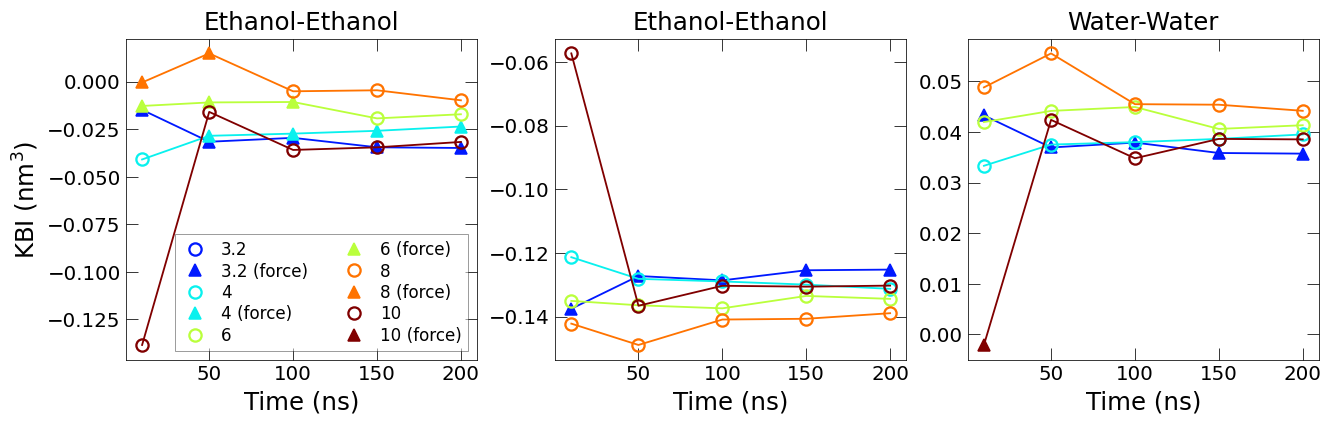

In [32]:
# first look at actual values for each boxlength over time

plot_kbi_vs_time(kbints, kbis_converged, kbis_forced, kbis_all, cmap="jet")

#### Plot specific boxsize and molecular pairs to evaluate *KBIConvergence*

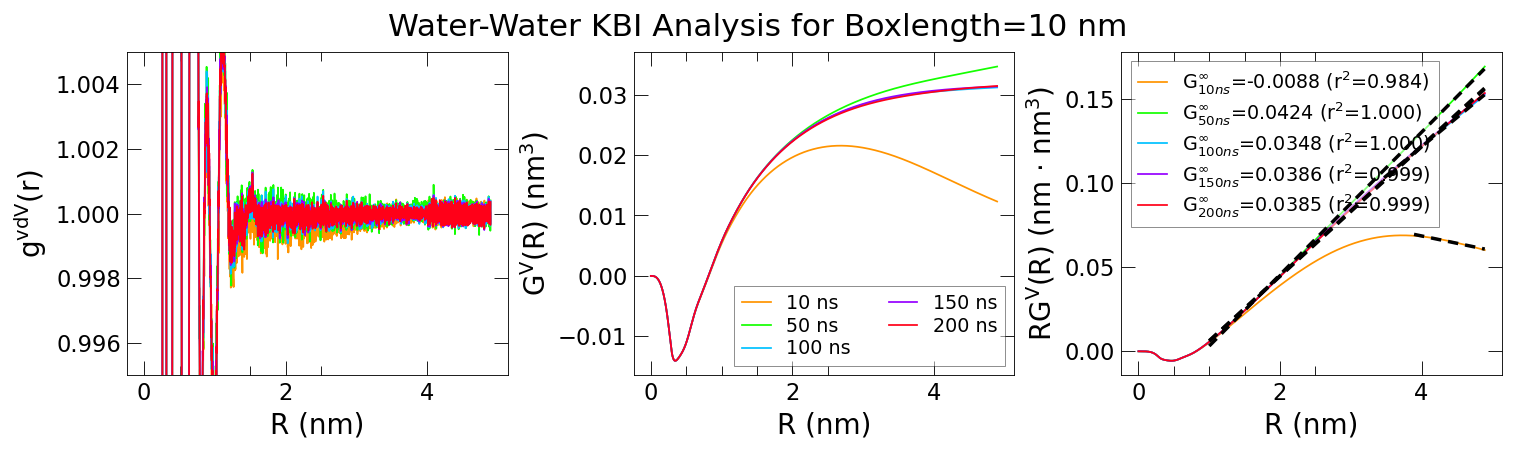

In [36]:
# note: criteria for convergence; r-range > 1.0 nm; r^2 > 0.99

plot_times(kbint_dict=kbints, key=10, mols=("spcew", "spcew"))

We see that for a 10 nm box, > 100 ns are required for sufficient convergence. 
When the box is too small; we see that the convergence fails and the RDF still exibits structure at large L.

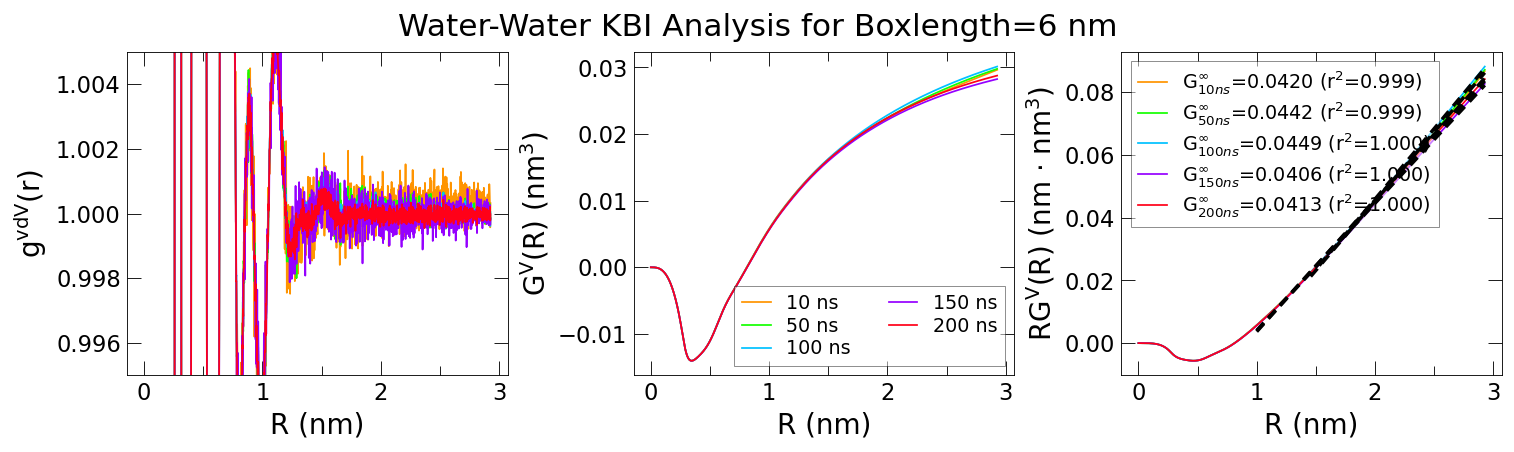

In [37]:
plot_times(kbint_dict=kbints, key=6, mols=("spcew", "spcew"))

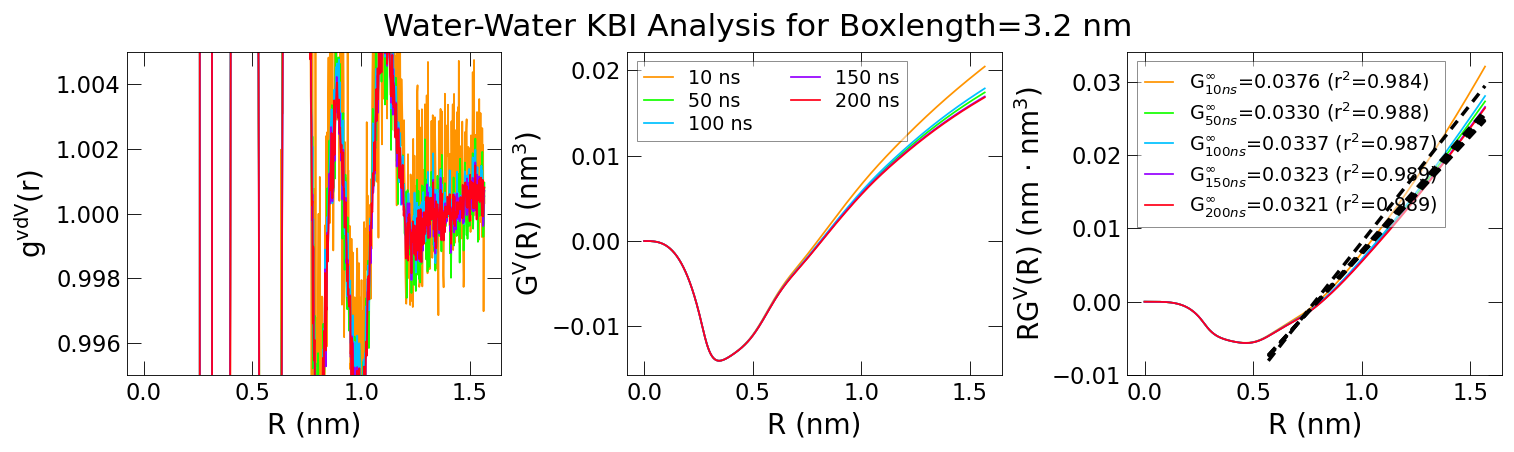

In [38]:
plot_times(kbint_dict=kbints, key=3.2, mols=("spcew", "spcew"))

#### Plot absolute percent deviation from KBI at 10 nm and 200 ns

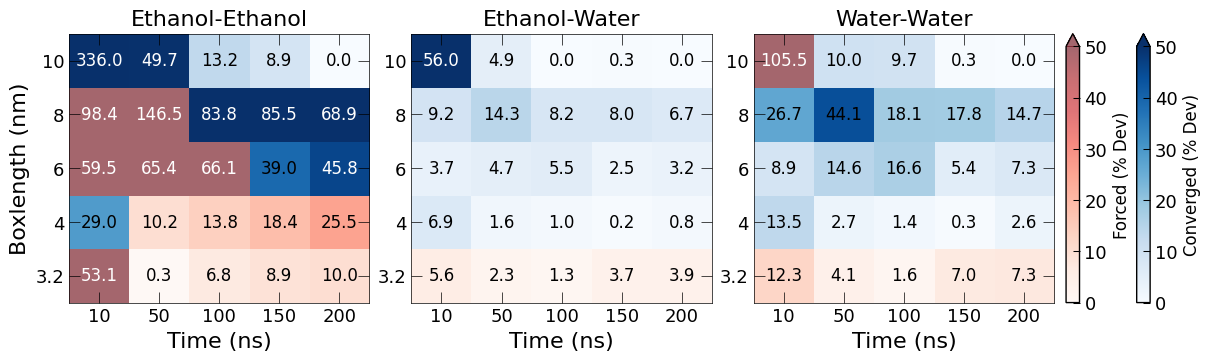

In [14]:
# get heatmap for each molecule-pair to visualize converged KBIs & percent deviation from 10 nm & 200 ns
# Create meshgrid for plotting
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)

for i, (mol1, mol2) in enumerate(mol_pairs):
    add_cbar = True if i == 2 else False
    plot_heatmap(axes[i], mol1, mol2, add_cbar=add_cbar)
    axes[i].set_title(f"{molmap[mol1]}-{molmap[mol2]}")
    axes[i].set_xlabel("Time (ns)")
    style_axes(axes[i])
axes[0].set_ylabel("Boxlength (nm)")

plt.show()

####  For a given molecule pair, compare extrapolation fits for each boxsize considered and the percent deviation heatmap

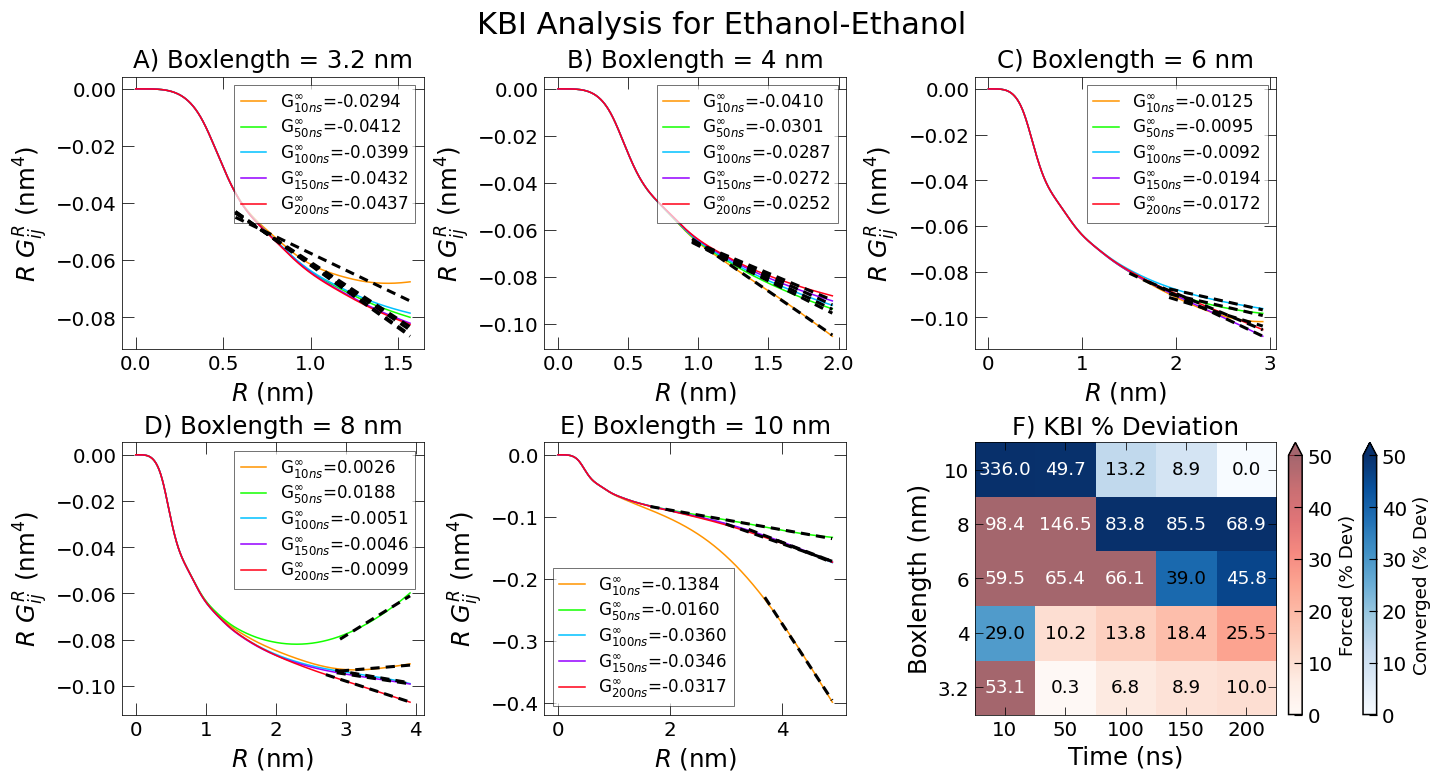

In [15]:
plot_rkbi_heatmap("ethol", "ethol")

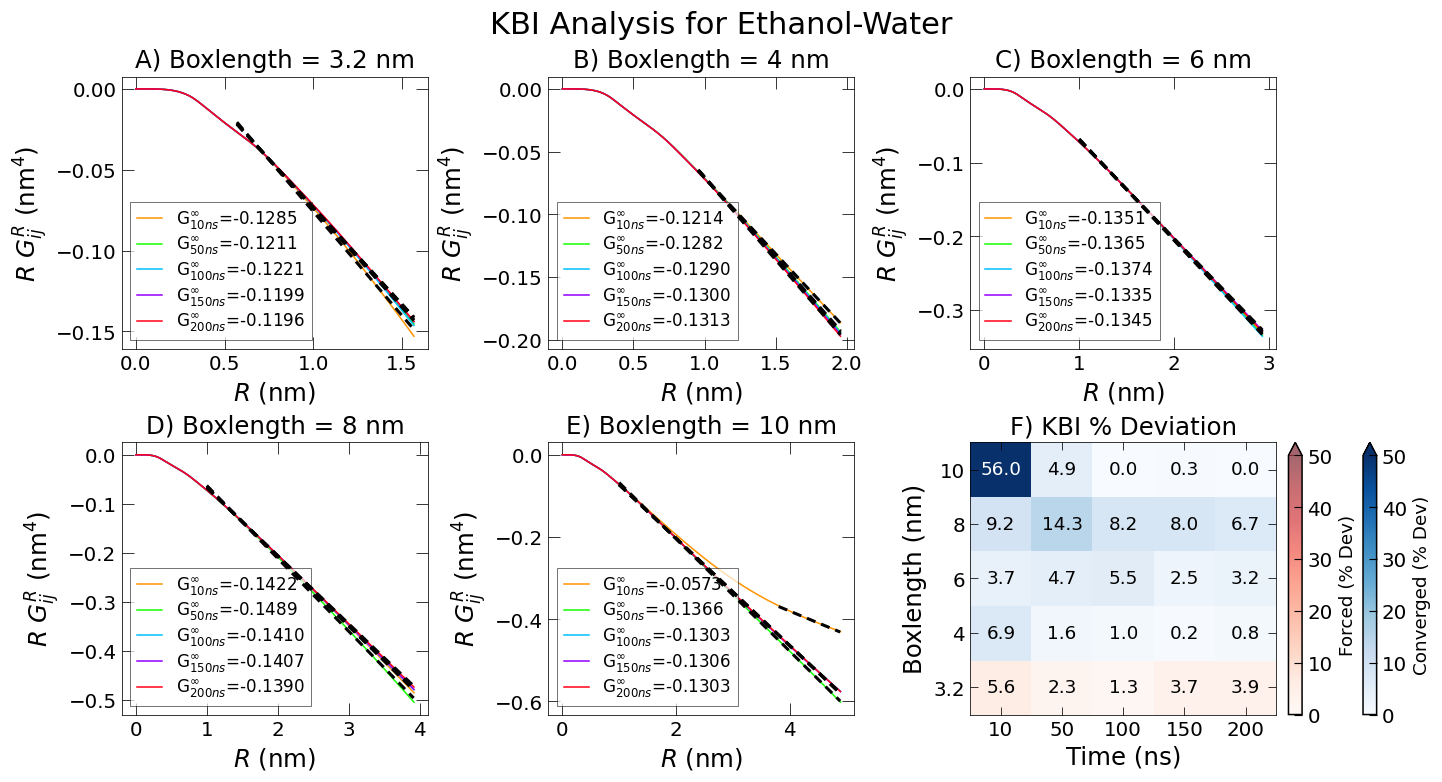

In [16]:
plot_rkbi_heatmap("ethol", "spcew")

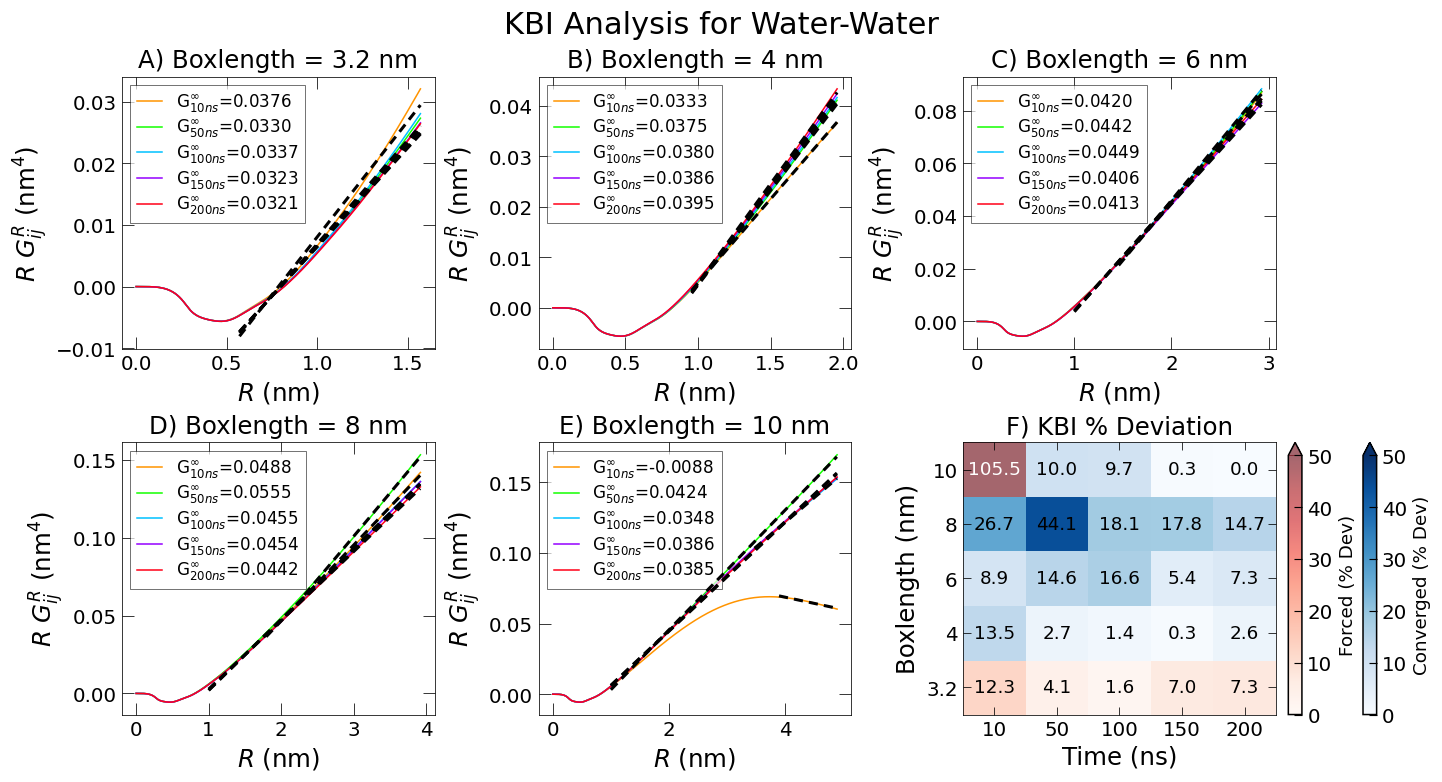

In [17]:
plot_rkbi_heatmap("spcew", "spcew")

### Initial configuration effects for a 8 nm boxlength

In [18]:
# here is a list of two systems under the same configuration; just packed via PACKMOL differently; i.e., different initial config.
replicates_8nm = ["sys_702", "sys_705"]

In [19]:
kbints_8nm = {0: {}, 1: {}}
for s, sys in enumerate(replicates_8nm):
    syspath = Path(f"./test_data/size_effects/{sys}")
    sysprop = SystemProperties(syspath, start_time=10000, include="npt")

    # get all rdf-paths
    rdf_paths = natsorted(syspath.glob("*rdf*ns*"))

    # now iterate through all rdf-paths
    for path in rdf_paths:
        time = extract_time(path.name)
        for f in natsorted(path.glob("*.xvg")):
            integ = KBIntegrator.from_rdf(rdf_file=f, system_properties=sysprop, errors="raise", force=False)
            rdf_mols = tuple(RdfParser.extract_molecules(f.name, sysprop.get("molecules")))
            kbints_8nm[s].setdefault(time, {})[rdf_mols] = integ

In [21]:
kbi_shape_8nm = len(replicates_8nm), len(times), len(mol_pairs)

kbis_converged_8nm = np.full(kbi_shape_8nm, fill_value=np.nan)
kbis_forced_8nm = np.full(kbi_shape_8nm, fill_value=np.nan)
kbis_all_8nm = np.full(kbi_shape_8nm, fill_value=np.nan)

for b, (L, boxdict) in enumerate(kbints_8nm.items()):
    for t, (time, timedict) in enumerate(boxdict.items()):
        for mols, integ in timedict.items():
            i = mol_pairs.index(mols)
            try:
                kbi = integ.kbi
                kbis_converged_8nm[b, t, i] = kbi
                kbis_all_8nm[b, t, i] = kbi
            except KBIConvergenceError as e:
                print(f"{L=}, {time=}: {e}")
                kbi_f = integ.compute_kbi(weight_type="u2")
                kbis_forced_8nm[b, t, i] = kbi_f
                kbis_all_8nm[b, t, i] = kbi_f

L=0, time=50: Could not find valid regression window with R^2 > 0.99 (best R^2 = 0.9859).
L=0, time=100: Could not find valid regression window with R^2 > 0.99 (best R^2 = 0.8914).
L=0, time=150: Could not find valid regression window with R^2 > 0.99 (best R^2 = 0.8640).
L=1, time=10: Could not find valid regression window with R^2 > 0.99 (best R^2 = 0.8647).
L=1, time=50: Could not find valid regression window with R^2 > 0.99 (best R^2 = 0.9887).


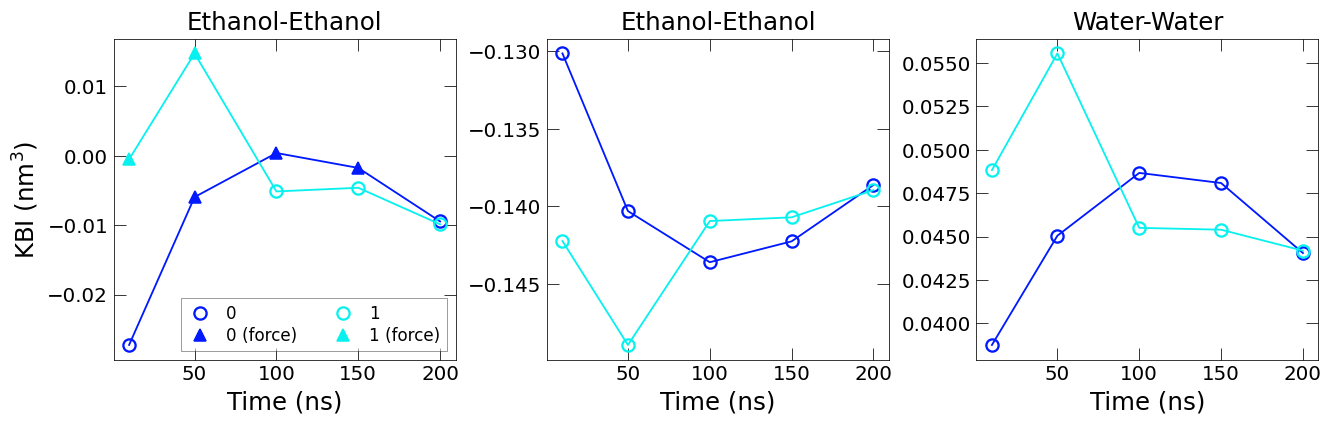

In [22]:
plot_kbi_vs_time(kbints_8nm, kbis_converged_8nm, kbis_forced_8nm, kbis_all_8nm, cmap="jet")

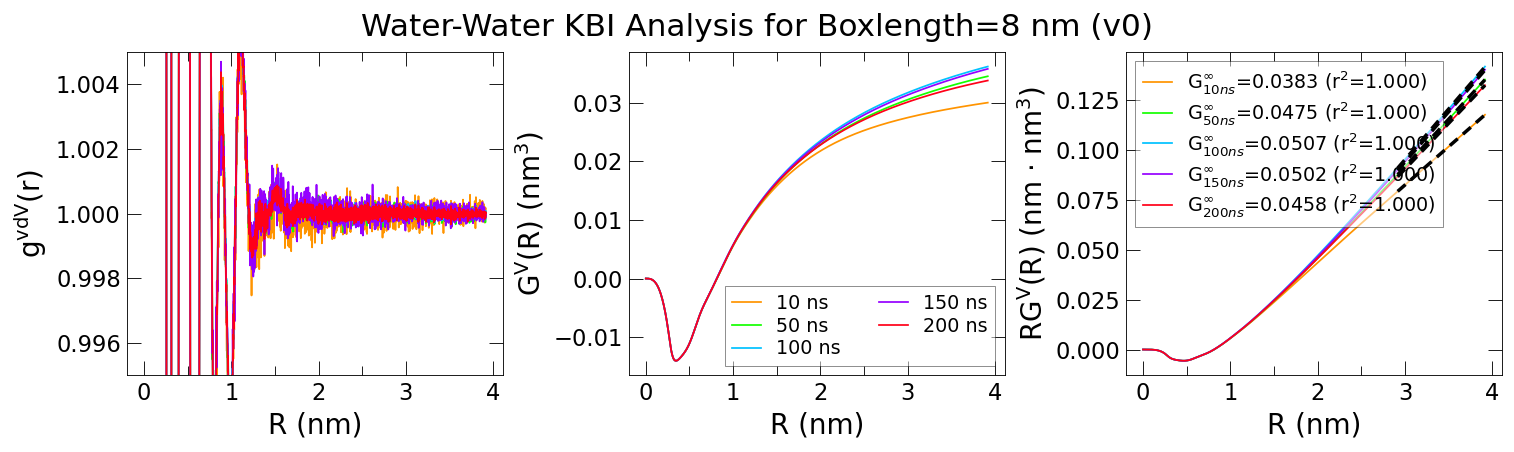

In [39]:
plot_times(kbint_dict=kbints_8nm, key=0, mols=("spcew", "spcew"))

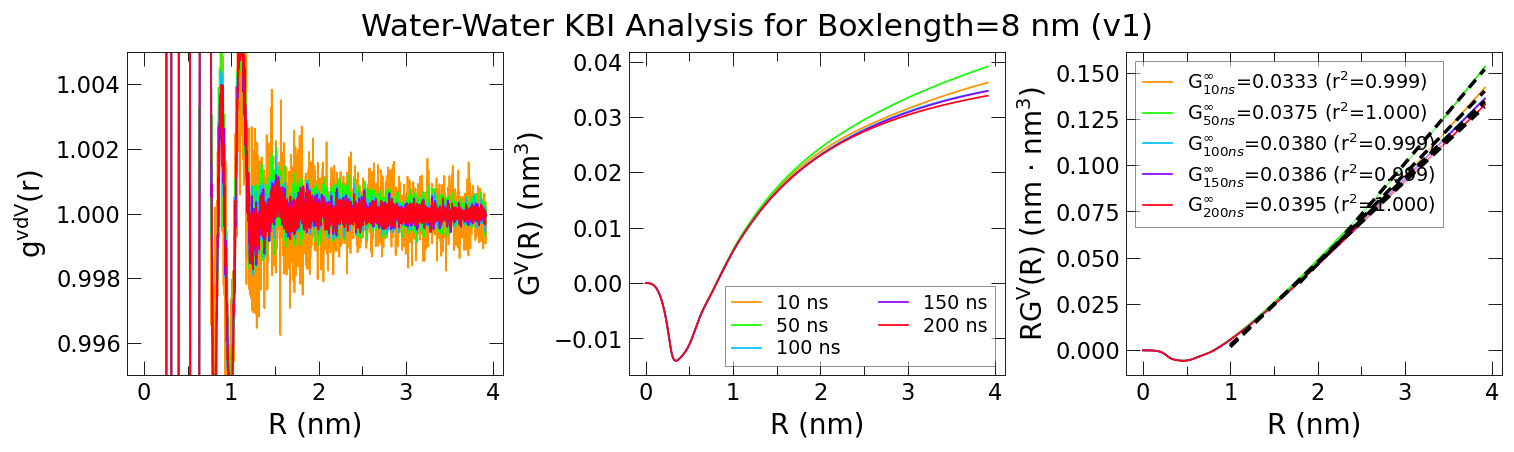

In [40]:
plot_times(kbint_dict=kbints_8nm, key=1, mols=("spcew", "spcew"))